# Data Exploration 3: Data Quality, Noise & Usability Rating

In this notebook, we shift focus from **what** the carts are doing to **how good** the data actually is. Hardware positioning data (like UWB, Bluetooth, or GPS indoors) is notoriously noisy.

We need to answer: How much of this data can we actually trust? How much is noise, and does the built-in quality metric (`q`) actually help us filter it?

### Quality Vectors We Will Analyze:
1. **Sampling Continuity & Dropouts:** How consistent is the ping rate? Do carts frequently drop offline?
2. **Out of Bounds Errors:** What percentage of our data thinks the cart is physically outside the store walls?
3. **Teleportation Rate (Spikes):** How often does a cart "jump" at physically impossible speeds (> 5 m/s)?
4. **Stationary Jitter (Hardware Precision):** When a cart is parked, how much does the tracker bounce around in place?
5. **Software Confidence (`q`):** Does the hardware's confidence level correlate with real-world errors?
6. **Final Dataset Usability Score:** What percentage of our raw database is actually clean enough to use for machine learning?

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')

## 1. Load Pristine Raw Data (No Filters Yet)
We must load the data exactly as it was recorded, without dropping the (0,0) charging points, so we can accurately measure the noise percentage.

In [2]:
raw_data_dir = '../data/raw'
all_files = glob.glob(os.path.join(raw_data_dir, 'node_*.csv'))

dfs = []
for f in all_files[:5]: # Loading 5 full files for solid sample size
    df = pd.read_csv(f, usecols=['node_id', 'timestamp', 'x', 'y', 'q'], 
                     dtype={'node_id': 'int32', 'x': 'float32', 'y': 'float32', 'q': 'uint8'})
    dfs.append(df)

raw_data = pd.concat(dfs, ignore_index=True)
del dfs
raw_data['timestamp'] = pd.to_datetime(raw_data['timestamp'])
raw_data = raw_data.sort_values(by=['node_id', 'timestamp'])

total_raw_rows = len(raw_data)
print(f"Total Raw Data Points Loaded: {total_raw_rows:,}")


Total Raw Data Points Loaded: 18,954,863


## 2. Sampling Continuity & Signal Dropouts
A good system logs continuously. A noisy system drops connection.

2. Sampling Continuity Metrics
------------------------------
Median Ping Frequency: Every 1.0 seconds
Total Signal Dropouts (> 10s gap mid-session): 205,299
Dropout Rate: 1.08% of all continuous pings


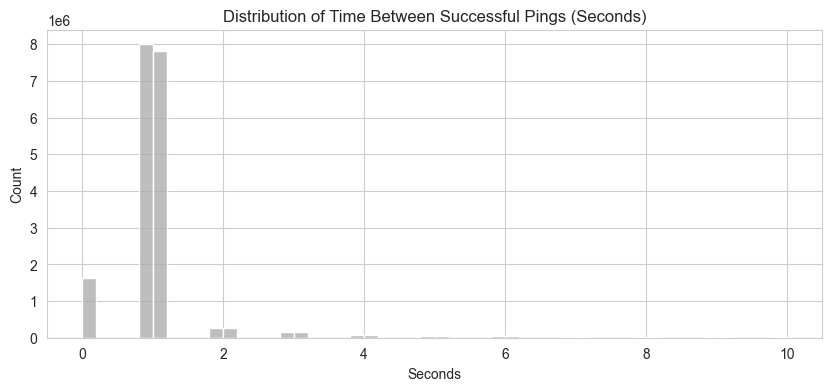

In [3]:
raw_data['time_diff'] = raw_data.groupby('node_id')['timestamp'].diff().dt.total_seconds()

valid_steps = raw_data[raw_data['time_diff'] > 0]
median_ping_rate = valid_steps['time_diff'].median()

# How many dropouts? A dropout is a gap > 10 seconds, but less than 30 minutes (session edge)
dropouts = raw_data[(raw_data['time_diff'] > 10) & (raw_data['time_diff'] < 1800)]
dropout_rate = (len(dropouts) / total_raw_rows) * 100

print("2. Sampling Continuity Metrics")
print("------------------------------")
print(f"Median Ping Frequency: Every {median_ping_rate:.1f} seconds")
print(f"Total Signal Dropouts (> 10s gap mid-session): {len(dropouts):,}")
print(f"Dropout Rate: {dropout_rate:.2f}% of all continuous pings")

plt.figure(figsize=(10, 4))
sns.histplot(valid_steps[valid_steps['time_diff'] < 10]['time_diff'], bins=50, color='darkgray')
plt.title('Distribution of Time Between Successful Pings (Seconds)')
plt.xlabel('Seconds')
plt.show()

## 3. Out of Bounds Rate (Physical Errors)
Based on previous mapping, the store is roughly between `X: 0 to 10406` and `Y: 0 to 5220`.
Any points beyond this are impossible hardware glitches (or charging stations at 0,0 registering incorrectly).

3. Physical Out-of-Bounds Metrics
---------------------------------
Charging Station (0,0) Errors: 26 (0.0%)
Physical Walls Breached (Glitch outside bounds): 3,701,336 (19.5%)


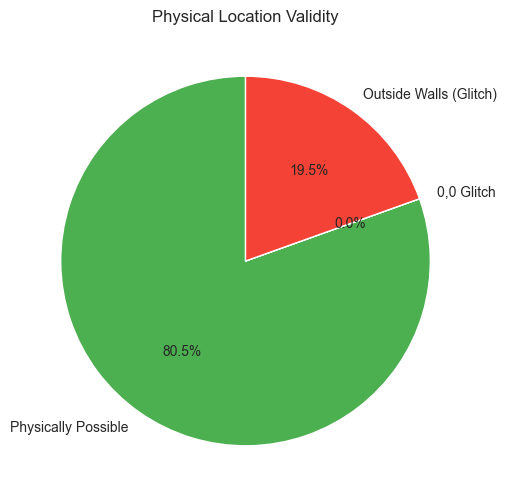

In [4]:
# Determine if a point is a charging station glitch
raw_data['is_charging_00'] = (raw_data['x'] == 0) & (raw_data['y'] == 0)

# Determine if a point is out of physical bounds
raw_data['out_of_bounds'] = (raw_data['x'] < 0) | (raw_data['x'] > 10500) | (raw_data['y'] < 0) | (raw_data['y'] > 5300)

charging_pts = raw_data['is_charging_00'].sum()
oob_pts = raw_data['out_of_bounds'].sum() - charging_pts # Avoid double counting 0,0 if bounds changed

charging_rate = (charging_pts / total_raw_rows) * 100
oob_rate = (oob_pts / total_raw_rows) * 100

print("3. Physical Out-of-Bounds Metrics")
print("---------------------------------")
print(f"Charging Station (0,0) Errors: {charging_pts:,} ({charging_rate:.1f}%)")
print(f"Physical Walls Breached (Glitch outside bounds): {oob_pts:,} ({oob_rate:.1f}%)")

plt.figure(figsize=(6, 6))
plt.pie([total_raw_rows - (charging_pts + oob_pts), charging_pts, oob_pts], 
        labels=['Physically Possible', '0,0 Glitch', 'Outside Walls (Glitch)'],
        autopct='%1.1f%%', colors=['#4CAF50', '#FFC107', '#F44336'], startangle=90)
plt.title('Physical Location Validity')
plt.show()

## 4. Teleportation / GPS Sprays (Noise Rate)
Even if a point is inside the store, did the cart travel at 20 m/s to get there? We flag "Teleportation" as moving faster than 5 meters per second.

In [5]:
raw_data['x_diff'] = raw_data.groupby('node_id')['x'].diff()
raw_data['y_diff'] = raw_data.groupby('node_id')['y'].diff()
raw_data['distance_m'] = np.sqrt(raw_data['x_diff']**2 + raw_data['y_diff']**2) / 100.0
raw_data['speed_ms'] = raw_data['distance_m'] / raw_data['time_diff'].replace(0, np.nan)

# Ignore session jumps (>30 mins) when calculating speed
valid_speed_checks = raw_data[(raw_data['time_diff'] > 0) & (raw_data['time_diff'] < 1800)].copy()

teleport_jumps = valid_speed_checks[valid_speed_checks['speed_ms'] > 5.0]
teleport_rate = (len(teleport_jumps) / len(valid_speed_checks)) * 100

print("4. Teleportation Spikes (Unrealistic Speeds)")
print("--------------------------------------------")
print(f"Total impossible jumps (> 5 m/s): {len(teleport_jumps):,}")
print(f"Teleportation Rate: {teleport_rate:.2f}% of all continuous movements")


4. Teleportation Spikes (Unrealistic Speeds)
--------------------------------------------
Total impossible jumps (> 5 m/s): 179,275
Teleportation Rate: 0.95% of all continuous movements


## 5. Stationary Jitter (Precision of the Hardware)
When a cart is parked and entirely stationary, does the coordinate lock on perfectly or "jitter" around?
We will find long periods where the cart hasn't realistically moved (speed near 0) and check the standard deviation of its X and Y coordinates.

In [6]:
# Find periods where speed is extremely low (< 0.1 m/s) implying parked.
# Exclude 0,0 bugs.
parked_data = raw_data[(raw_data['speed_ms'] < 0.1) & (~raw_data['is_charging_00'])].copy()

x_jitter = parked_data['x_diff'].std()
y_jitter = parked_data['y_diff'].std()
overall_jitter = np.sqrt(x_jitter**2 + y_jitter**2)

print("5. Stationary Jitter (Hardware Precision)")
print("-----------------------------------------")
print(f"X-Axis Jitter: +/- {x_jitter:.1f} cm")
print(f"Y-Axis Jitter: +/- {y_jitter:.1f} cm")
print(f"Overall Stationary Drift Radius: {overall_jitter:.1f} cm")
print(f"\nMeaning: If a cart is parked, the computer thinks it is vibrating within a {overall_jitter/100:.2f} meter circle.")

5. Stationary Jitter (Hardware Precision)
-----------------------------------------
X-Axis Jitter: +/- 41.9 cm
Y-Axis Jitter: +/- 68.7 cm
Overall Stationary Drift Radius: 80.4 cm

Meaning: If a cart is parked, the computer thinks it is vibrating within a 0.80 meter circle.


## 6. Software Confidence (`q`) - Does it help us?
The raw data includes a quality metric `q`. Does low `q` actually correspond with our calculated "Bad" data (Out of bounds or teleporting)?

6. Software Confidence (`q`) Distribution
-----------------------------------------
Average `q` value for GOOD data: 67.6
Average `q` value for BAD data:  60.3


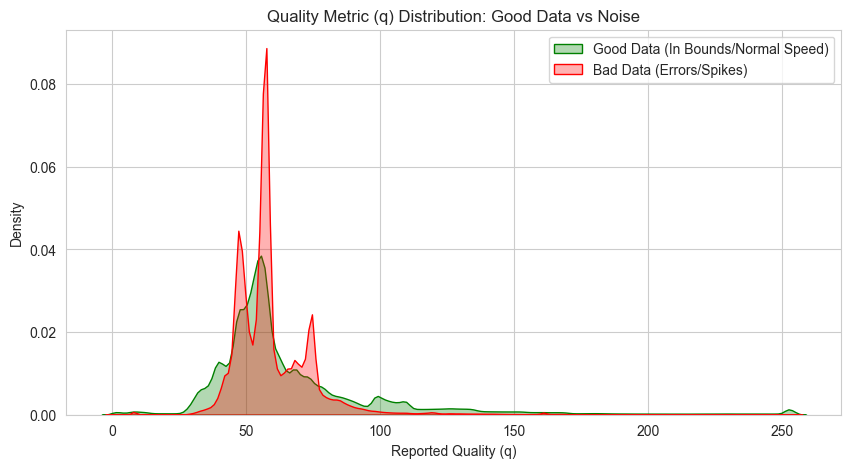

In [7]:
raw_data['is_bad_data'] = raw_data['out_of_bounds'] | raw_data['is_charging_00'] | (raw_data['speed_ms'] > 5.0)

good_data_q = raw_data[~raw_data['is_bad_data']]['q']
bad_data_q = raw_data[raw_data['is_bad_data']]['q']

print("6. Software Confidence (`q`) Distribution")
print("-----------------------------------------")
print(f"Average `q` value for GOOD data: {good_data_q.mean():.1f}")
print(f"Average `q` value for BAD data:  {bad_data_q.mean():.1f}")

plt.figure(figsize=(10, 5))
sns.kdeplot(good_data_q, label='Good Data (In Bounds/Normal Speed)', fill=True, color='green', alpha=0.3)
sns.kdeplot(bad_data_q.dropna(), label='Bad Data (Errors/Spikes)', fill=True, color='red', alpha=0.3)
plt.title('Quality Metric (q) Distribution: Good Data vs Noise')
plt.xlabel('Reported Quality (q)')
plt.legend()
plt.show()

## 7. Final Dataset Usability Score
We will now rate the overall database. What percentage of the recorded lines are **Clean, Realistic, and ML-Ready** without requiring heavy smoothing?

     FINAL DATA USABILITY SCORE RATING   
Clean, Usable Data Points: 15,108,471 out of 18,954,863
Usability Score: 79.7 / 100

Conclusion: GOOD. Noticeable hardware noise exists, but standard filtering yields great results.


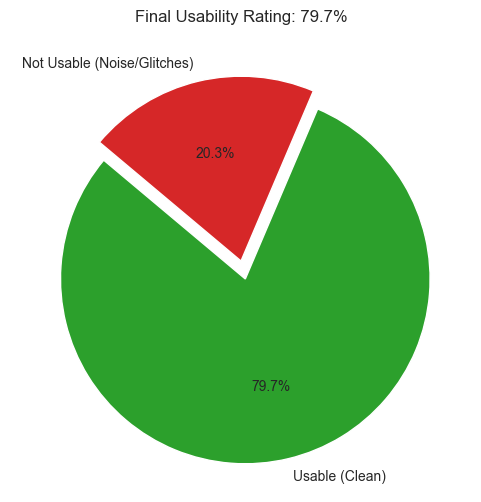

In [8]:
clean_ready_points = total_raw_rows - raw_data['is_bad_data'].sum()
usability_score = (clean_ready_points / total_raw_rows) * 100

print("=========================================")
print("     FINAL DATA USABILITY SCORE RATING   ")
print("=========================================")
print(f"Clean, Usable Data Points: {clean_ready_points:,} out of {total_raw_rows:,}")
print(f"Usability Score: {usability_score:.1f} / 100\n")

if usability_score > 90:
    print("Conclusion: EXCELLENT. The data is highly reliable and requires minimal filtering.")
elif usability_score > 70:
    print("Conclusion: GOOD. Noticeable hardware noise exists, but standard filtering yields great results.")
elif usability_score > 50:
    print("Conclusion: MEDIOCRE. The hardware generates a lot of phantom data. Aggressive filtering is mandatory.")
else:
    print("Conclusion: POOR. More noise than signal. The hardware tracking implementation may need review.")

plt.figure(figsize=(6, 6))
plt.pie([usability_score, 100-usability_score], labels=['Usable (Clean)', 'Not Usable (Noise/Glitches)'], 
        autopct='%1.1f%%', colors=['#2ca02c', '#d62728'], startangle=140, explode=(0.1, 0))
plt.title(f'Final Usability Rating: {usability_score:.1f}%')
plt.show()